## RandomizedSearch CV to find optimal parameters for the XGBoost classifier in Kaggle Credit Card dataset

In [8]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]), sep=",")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


1. Preprocessing data (explained in preliminary_data_analysis.ipynb)

In [3]:
# @title
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import kagglehub
import os

import xgboost as xgb


In [4]:
# @title
def boxplot_bounds(series, whis=1.5):
  s = series.dropna()
  q1 = s.quantile(0.25)
  q3 = s.quantile(0.75)
  iqr = q3 - q1
  low = q1 - whis * iqr
  high = q3 + whis * iqr
  return low, high

def apply_bounds(df, f, low, high, fill):
  df = df.copy()
  mask = (df[f] < low) | (df[f] > high)
  df.loc[mask, f] = fill
  return df

In [5]:
# @title
class DataPreprocessing():

  def __init__(self):
    self.nans = None
    self.medians_nan = None
    self.median_amount  = None


  def fit(self, X):
    self.nans = X.columns[X.isna().any()].tolist()
    self.medians_nan = X[self.nans].median()
    self.median_amount = X["Amount"].median()


  def transform(self, X):
    X = X.copy()

    if self.nans:
      X[self.nans] = X[self.nans].fillna(self.medians_nan)


    return X

In [6]:
# @title
def auc_score_vis(pred_proba):
  fpr, tpr, _ = roc_curve(y_valid, pred_proba)
  auc_score = roc_auc_score(y_valid, pred_proba)

  plt.plot(fpr, tpr, label=f"roc_auc_score = {auc_score}")
  plt.ylabel('True Positive Rate')
  plt.xlabel('False Positive Rate')
  plt.legend(loc='lower right')
  plt.show()

In [7]:
# @title
def reduce_mem_usage(df):

    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

In [9]:
# @title
df = reduce_mem_usage(df)
TARGET_NAME = 'Class'

train, valid = train_test_split(
    df,
    test_size=0.33,
    random_state=42,
    shuffle=True,
    stratify=df[TARGET_NAME]
    )


Memory usage of dataframe is 67.36 MB
Memory usage after optimization is: 32.87 MB
Decreased by 51.2%


In [10]:
# @title
amt = train['Amount']
amt_cond = (amt<0.1) | (amt>500)
train.loc[amt_cond, 'Amount'] = amt.median()

In [11]:
# @title
NO_TARGET_FEATURES_TRAIN = train.drop(columns=[TARGET_NAME, 'Amount'])

preprocessor = DataPreprocessing()
preprocessor.fit(train)
train = preprocessor.transform(train)
valid = preprocessor.transform(valid)


NO_TARGET_NAMES = NO_TARGET_FEATURES_TRAIN.columns.tolist()
bounds = {}
fills = {}

for f in NO_TARGET_NAMES:
  low, high = boxplot_bounds(train[f], whis=1.5)
  bounds[f] = (low, high)
  fills[f] = train[f].median()

for f in NO_TARGET_NAMES:
  low, high = bounds[f]
  fill = fills[f]
  train = apply_bounds(train, f, low, high, fill)
  valid = apply_bounds(valid, f, low, high, fill)

2. Search of hyperparameters

In [12]:
X_train = train.drop(columns=TARGET_NAME)
X_valid = valid.drop(columns=TARGET_NAME)
y_train = train[TARGET_NAME]
y_valid = valid[TARGET_NAME]

Parameter `scale_pos_weight`: add more weight to the positive classes. Normally calculated as: sum(negative instances) / sum(positive instances)

In [13]:
# calculating scale_pos_weight
scale_weight = round(sum(y_train==0)/ sum(y_train==1),0)
scale_weight

577.0

Add new features to try catch silent FNs

In [14]:
def add_features(df):
  df['High_amount']=(df['Amount']>200).astype(int)
  df['Sum_features']=df[['V2', 'V4', 'V6', 'V1']].abs().sum(axis=1)
  df['V4_Amount'] = df['V4'] * df['Amount']
  df['V2_Amount'] = df['V2'] * df['Amount']
  df['V1_sq'] = df['V1']**2
  df['V6_sq'] = df['V6']**2
  return df

In [15]:
X_train_f = add_features(X_train)
X_valid_f = add_features(X_valid)

Preparing a pipeline

In [16]:
cvv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
params_xgb = {
    "clf__n_estimators"     : [100, 200, 300],
    "clf__learning_rate"    : [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth"        : [3, 4, 5, 6],
    "clf__min_child_weight" : [1, 2],
    'clf__scale_pos_weight': [500, 570, 650],
    'clf__subsample': [0.7, 0.8, 0.9],
    'clf__colsample_bytree': [0.7, 0.8, 0.9],
    'clf__max_delta_step': [1,2]
}

pipe_xgb = ImbPipeline([
    ("scaler", MinMaxScaler()),
    ("clf", xgb.XGBClassifier(random_state=42))
])

rs_xgb = RandomizedSearchCV(
    pipe_xgb,
    params_xgb,
    scoring = "average_precision", # to focus on average precision
    cv      = cvv,
    n_iter  = 25,
    n_jobs  = -1,
    verbose=1
    )

rs_xgb.fit(X_train_f, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                             ('clf',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric=None,
                                                            featur...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'clf__colsample_bytree': [0.7, 0.8,
                                                                  0.9],
                                        'clf__learning_rate': [0.01, 0.05, 0.1,
                                                               0.2],
                                        'clf__max_delta_step': [1, 2],
                                        'clf__max_depth': [3, 4, 5, 6],
                                        'clf__min_child_weight': [1, 2],
                                        'clf__n_estimators': [100, 200, 300],
                                        'clf__scale_pos_weight': [500, 570,
                                                                  650],
                                        'clf__subsample': [0.7, 0.8, 0.9]},
                   scoring='average_precision', verbose=1)

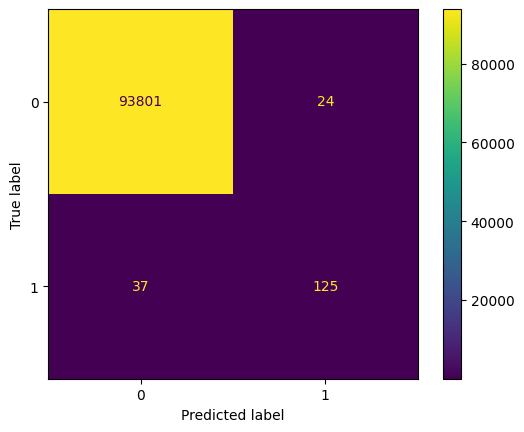

In [18]:
best_model = rs_xgb.best_estimator_
ConfusionMatrixDisplay.from_estimator(best_model, X_valid_f, y_valid)

In [20]:
print("Recall achieved during CV:", rs_xgb.best_score_)
print("The Magic Parameters:", rs_xgb.best_params_)

Recall achieved during CV: 0.8320495293433534
The Magic Parameters: {'clf__subsample': 0.7, 'clf__scale_pos_weight': 650, 'clf__n_estimators': 200, 'clf__min_child_weight': 2, 'clf__max_depth': 6, 'clf__max_delta_step': 2, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.7}


In [19]:
y_pred = best_model.predict(X_valid_f)
fn=X_valid_f[(y_valid==1) & (y_pred==0)] # 36 False Negatives
fn[['Amount','High_amount','Sum_features','V4_Amount','V2_Amount','V1_sq','V6_sq']].describe()

,Amount,High_amount,Sum_features,V4_Amount,V2_Amount,V1_sq,V6_sq
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,214.033508,0.405405,4.022249,114.090691,-87.928879,2.731957,0.982792
std,263.504852,0.497743,1.774936,303.577423,341.540100,3.782672,1.392313
min,0.000000,0.000000,1.119811,-721.066711,-1186.987549,0.000054,0.000088
25%,3.790000,0.000000,2.704160,-0.061458,-0.001595,0.040967,0.102624
50%,104.809998,0.000000,4.236978,6.472096,3.455377,1.214067,0.295478
75%,319.200012,1.000000,4.765164,213.960251,20.459949,3.744018,1.360379
max,1096.989990,1.000000,8.029417,1210.692505,422.096222,16.516136,5.426956


The frauds y missing actually have a stronger total signal (4.01) than the ones we are catching (3.20). This confirms that these 36 cases are very unique. They aren't "quiet"; they are just "different."

Let's try change parameters.

In [21]:
pipe_xgb_2 = ImbPipeline([
    ("scaler", MinMaxScaler()),
    ("clf", xgb.XGBClassifier(
        subsample=0.8,
        scale_pos_weight=650,
        n_estimators= 500,
        min_child_weight= 0.5,
       max_depth=12,
        max_delta_step= 1,
        learning_rate=0.05,
        colsample_bytree= 0.8
        ))
])

In [22]:
pipe_xgb_2.fit(X_train_f, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=1,
                               max_depth=12, max_leaves=None,
                               min_child_weight=0.5, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

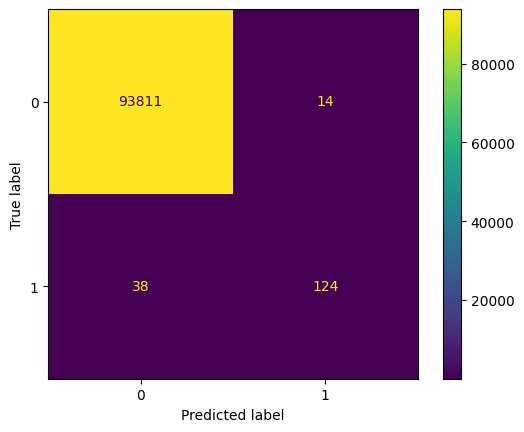

In [23]:
ConfusionMatrixDisplay.from_estimator(pipe_xgb_2, X_valid_f, y_valid)

As a result, we see that we minimized False Positives and False Negatives.  
We can take these parameters as optimal for the SageMaker training job.